# Part 2 — Supervised Machine Learning: Regression & Classification

**Input:** `cleaned_data.csv` from Part 1 (1500 rows).

- **Regression target (`y_reg`):** `annual_charges` (continuous)
- **Classification target (`y_clf`):** `smoker` (binarized: 1 = yes, 0 = no) — chosen instead of median-splitting `annual_charges`, because that split came out perfectly balanced (750/750) and would leave nothing to demonstrate for the required imbalance-handling task. `smoker` is a natural binary column already in the dataset with genuine imbalance (~22% positive).

See `README.md` for full written interpretation of every result (coefficients, precision/recall formulas, AUC meaning, regularization, bootstrap CI).

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score,
)
from imblearn.over_sampling import SMOTE

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## Task 1: Load Data & Define Labels

In [117]:
df = pd.read_csv("cleaned_data.csv")
print(df.head())
print(df.shape)

   age     sex    bmi  children smoker     region exercise_freq  prior_conditions  annual_charges
0   48    male  38.64       1.0     no  northeast      moderate               1.0         4650.06
1   51  female  28.26       0.0     no  northwest           NaN               0.0          642.04
2   44  female  34.75       3.0     no  northwest           low               0.0         6130.97
3   43  female  24.74       0.0    yes  northeast      moderate               0.0        22027.02
4   31  female  35.76       2.0     no  northeast           NaN               1.0         8132.21
(1500, 9)


In [118]:
y_reg = df["annual_charges"].copy()
y_clf = (df["smoker"] == "yes").astype(int)

print("y_reg (regression target) = 'annual_charges' (continuous)")
print("y_clf (classification target) = 'smoker' binarized (1=yes, 0=no)")
print(f"y_clf value counts:\n{y_clf.value_counts()}")
print(f"y_clf class balance: {y_clf.mean()*100:.1f}% positive (smoker=yes)")

y_reg (regression target) = 'annual_charges' (continuous)
y_clf (classification target) = 'smoker' binarized (1=yes, 0=no)
y_clf value counts:
smoker
0    1169
1     331
Name: count, dtype: int64
y_clf class balance: 22.1% positive (smoker=yes)


**Important leakage note:** two different feature sets are built to avoid leakage in *each* direction:
- `X_reg` excludes only `annual_charges` (its own target). `smoker` is a legitimate predictive **feature** for charges (not the regression target) and is in fact the single strongest cost driver identified in Part 1 — excluding it would artificially cripple the regression model.
- `X_clf` excludes **both** `annual_charges` and `smoker`, since `smoker` is the classification target itself here; leaving it in would let the model trivially "predict" its own label.

In [119]:
def encode_categoricals(X_raw, onehot_cols):
    X_enc = X_raw.copy()
    # exercise_freq has a natural order: none < low < moderate < high.
    # ~25% missing (from Part 1, exceeded the 20% threshold and was left
    # un-imputed there); mode-filled here since ordinal encoding needs a
    # category per row.
    mode_val = X_enc["exercise_freq"].mode()[0]
    n_missing = X_enc["exercise_freq"].isnull().sum()
    X_enc["exercise_freq"] = X_enc["exercise_freq"].fillna(mode_val)
    order_map = {"none": 0, "low": 1, "moderate": 2, "high": 3}
    X_enc["exercise_freq"] = X_enc["exercise_freq"].map(order_map)
    print(f"  Filled {n_missing} missing 'exercise_freq' with mode = '{mode_val}', "
          f"then label-encoded using order {order_map}")
    # sex/smoker/region have NO natural order -> one-hot, drop first
    X_enc = pd.get_dummies(X_enc, columns=onehot_cols, drop_first=True)
    print(f"  One-hot encoded {onehot_cols} (drop_first=True)")
    return X_enc

X_reg_raw = df.drop(columns=["annual_charges"]).copy()
X_clf_raw = df.drop(columns=["annual_charges", "smoker"]).copy()

## Task 2: Encode Categorical Columns\n\n`exercise_freq` has a natural order (none < low < moderate < high) → ordinal label encoding. `sex`, `smoker`, `region` have no natural order → one-hot encoding with `drop_first=True` to avoid multicollinearity and to avoid label encoding falsely implying an ordinal relationship between unordered categories (e.g. implying `northeast < northwest`, which has no real meaning).

In [120]:
print("Encoding X_reg (includes 'smoker' as a feature):")
X_reg = encode_categoricals(X_reg_raw, onehot_cols=["sex", "smoker", "region"])
print(f"X_reg columns: {list(X_reg.columns)}")

Encoding X_reg (includes 'smoker' as a feature):
  Filled 375 missing 'exercise_freq' with mode = 'low', then label-encoded using order {'none': 0, 'low': 1, 'moderate': 2, 'high': 3}
  One-hot encoded ['sex', 'smoker', 'region'] (drop_first=True)
X_reg columns: ['age', 'bmi', 'children', 'exercise_freq', 'prior_conditions', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [121]:
print("Encoding X_clf (excludes 'smoker' -- it's the classification target):")
X_clf = encode_categoricals(X_clf_raw, onehot_cols=["sex", "region"])
print(f"X_clf columns: {list(X_clf.columns)}")

Encoding X_clf (excludes 'smoker' -- it's the classification target):
  Filled 375 missing 'exercise_freq' with mode = 'low', then label-encoded using order {'none': 0, 'low': 1, 'moderate': 2, 'high': 3}
  One-hot encoded ['sex', 'region'] (drop_first=True)
X_clf columns: ['age', 'bmi', 'children', 'exercise_freq', 'prior_conditions', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest']


## Task 3: Leak-Free Train-Test Split & Scaling

Each `StandardScaler` is fit **only** on its training split, then used to transform both train and test sets. Fitting the scaler on the full dataset (before splitting) would leak test-set mean/standard-deviation statistics into training — the model would implicitly "see" information about the test set's distribution before evaluation, inflating apparent performance in a way that would not generalize to genuinely new data.

In [122]:
Xr_train, Xr_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"[Regression] Train shape: {Xr_train.shape}, Test shape: {Xr_test.shape}")

scaler_reg = StandardScaler()
scaler_reg.fit(Xr_train)
Xr_train_scaled = scaler_reg.transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

[Regression] Train shape: (1200, 10), Test shape: (300, 10)


In [123]:
Xc_train, Xc_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print(f"[Classification] Train shape: {Xc_train.shape}, Test shape: {Xc_test.shape}")

scaler_clf = StandardScaler()
scaler_clf.fit(Xc_train)
Xc_train_scaled = scaler_clf.transform(Xc_train)
Xc_test_scaled = scaler_clf.transform(Xc_test)

[Classification] Train shape: (1200, 9), Test shape: (300, 9)


## Task 4: Regression — Linear Regression

In [124]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, y_reg_train)
y_pred_reg = lin_reg.predict(Xr_test_scaled)

mse_lin = mean_squared_error(y_reg_test, y_pred_reg)
r2_lin = r2_score(y_reg_test, y_pred_reg)
print(f"Linear Regression -> MSE: {mse_lin:.2f} | R2: {r2_lin:.4f}")

Linear Regression -> MSE: 47595098.38 | R2: 0.5928


In [125]:
coef_table = pd.DataFrame({"feature": X_reg.columns, "coefficient": lin_reg.coef_})
coef_table["abs_coef"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False)
print(coef_table)

top3 = coef_table.head(3)
print(f"\nTop 3 features by |coefficient|: {top3['feature'].tolist()}")

            feature  coefficient     abs_coef
6        smoker_yes  7149.495382  7149.495382
4  prior_conditions  1193.764911  1193.764911
2          children   709.019918   709.019918
3     exercise_freq  -675.316625   675.316625
0               age   513.598562   513.598562
1               bmi   328.208077   328.208077
7  region_northwest  -171.032692   171.032692
9  region_southwest  -167.478106   167.478106
8  region_southeast    92.146639    92.146639
5          sex_male    -2.654212     2.654212

Top 3 features by |coefficient|: ['smoker_yes', 'prior_conditions', 'children']


### Ridge Regression (alpha=1.0)

In [126]:
ridge = Ridge(alpha=1.0)
ridge.fit(Xr_train_scaled, y_reg_train)
y_pred_ridge = ridge.predict(Xr_test_scaled)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)
print(f"Ridge Regression (alpha=1.0) -> MSE: {mse_ridge:.2f} | R2: {r2_ridge:.4f}")

Ridge Regression (alpha=1.0) -> MSE: 47608932.27 | R2: 0.5927


In [127]:
ridge_coef_table = pd.DataFrame({
    "feature": X_reg.columns, "linear_coef": lin_reg.coef_, "ridge_coef": ridge.coef_
})
print(ridge_coef_table)

comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (alpha=1.0)"],
    "MSE": [mse_lin, mse_ridge],
    "R2": [r2_lin, r2_ridge],
})
print(comparison_table)

            feature  linear_coef   ridge_coef
0               age   513.598562   513.131215
1               bmi   328.208077   327.961644
2          children   709.019918   708.731189
3     exercise_freq  -675.316625  -674.955836
4  prior_conditions  1193.764911  1192.627526
5          sex_male    -2.654212    -2.888534
6        smoker_yes  7149.495382  7143.523260
7  region_northwest  -171.032692  -170.963140
8  region_southeast    92.146639    91.872843
9  region_southwest  -167.478106  -167.593021
               Model           MSE        R2
0  Linear Regression  4.759510e+07  0.592790
1  Ridge (alpha=1.0)  4.760893e+07  0.592672


## Task 5: Classification — Logistic Regression

First check training-set class balance to decide whether imbalance handling is required.

In [128]:
print("y_clf_train value counts:")
print(y_clf_train.value_counts())
pct_minority = y_clf_train.value_counts(normalize=True).min() * 100
print(f"Minority class share: {pct_minority:.1f}%")

use_class_weight = pct_minority < 35
if use_class_weight:
    print("\nMinority class < 35% -> imbalance handling required.")
    print("Chosen strategy: class_weight='balanced' in LogisticRegression")
    print("(see README for justification vs. SMOTE).")

y_clf_train value counts:
smoker
0    932
1    268
Name: count, dtype: int64
Minority class share: 22.3%

Minority class < 35% -> imbalance handling required.
Chosen strategy: class_weight='balanced' in LogisticRegression
(see README for justification vs. SMOTE).


In [129]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced" if use_class_weight else None)
log_reg.fit(Xc_train_scaled, y_clf_train)
y_pred_clf = log_reg.predict(Xc_test_scaled)
y_proba_clf = log_reg.predict_proba(Xc_test_scaled)[:, 1]

cm = confusion_matrix(y_clf_test, y_pred_clf)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf))

Confusion Matrix:
[[138  99]
 [ 29  34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.58      0.68       237
           1       0.26      0.54      0.35        63

    accuracy                           0.57       300
   macro avg       0.54      0.56      0.52       300
weighted avg       0.71      0.57      0.61       300



### ROC Curve & AUC

AUC: 0.5586


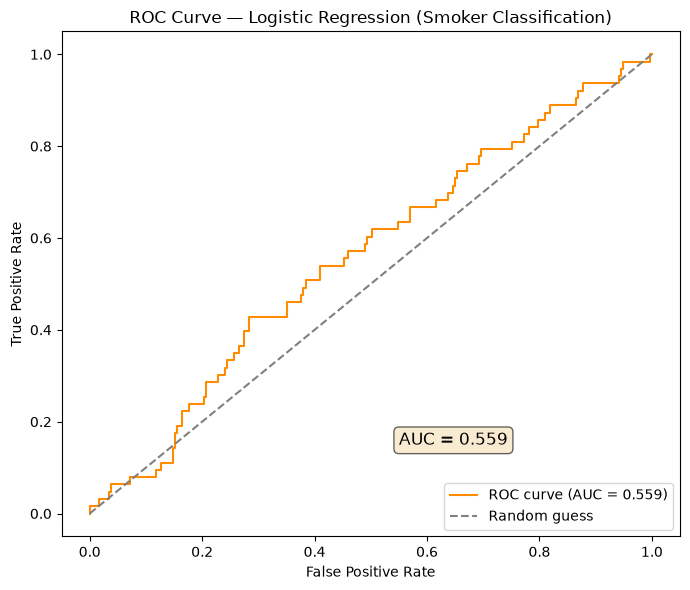

In [130]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)
auc = roc_auc_score(y_clf_test, y_proba_clf)
print(f"AUC: {auc:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Smoker Classification)")
plt.annotate(f"AUC = {auc:.3f}", xy=(0.55, 0.15), fontsize=12,
             bbox=dict(boxstyle="round", fc="wheat", alpha=0.6))
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots/roc_curve.png", dpi=120)
plt.show()

### Imbalance Handling — Before/After Comparison\n\n`class_weight='balanced'` was the chosen production strategy (reweights the loss function, does not change row counts). For comparison, we also show what SMOTE oversampling would have produced.

In [131]:
print("BEFORE (raw training class counts):")
print(y_clf_train.value_counts())

if use_class_weight:
    smote = SMOTE(random_state=42)
    Xc_train_res, y_clf_train_res = smote.fit_resample(Xc_train_scaled, y_clf_train)
    print("\nAFTER (if SMOTE were applied instead, for comparison):")
    print(pd.Series(y_clf_train_res).value_counts())

BEFORE (raw training class counts):
smoker
0    932
1    268
Name: count, dtype: int64

AFTER (if SMOTE were applied instead, for comparison):
smoker
0    932
1    932
Name: count, dtype: int64


## Task 5b: Decision-Threshold Sensitivity (0.30 → 0.70)

In [132]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_rows = []
for t in thresholds_to_test:
    preds_t = (y_proba_clf >= t).astype(int)
    p = precision_score(y_clf_test, preds_t, zero_division=0)
    r = recall_score(y_clf_test, preds_t, zero_division=0)
    f1 = f1_score(y_clf_test, preds_t, zero_division=0)
    threshold_rows.append({"Threshold": t, "Precision": p, "Recall": r, "F1": f1})

threshold_table = pd.DataFrame(threshold_rows)
print(threshold_table)

best_row = threshold_table.loc[threshold_table["F1"].idxmax()]
print(f"\nThreshold maximizing F1: {best_row['Threshold']} (F1={best_row['F1']:.4f})")

   Threshold  Precision    Recall        F1
0        0.3   0.210000  1.000000  0.347107
1        0.4   0.213287  0.968254  0.349570
2        0.5   0.255639  0.539683  0.346939
3        0.6   0.235294  0.063492  0.100000
4        0.7   0.000000  0.000000  0.000000

Threshold maximizing F1: 0.4 (F1=0.3496)


## Task 6: Regularization Experiment (C=1.0 vs C=0.01)

In [133]:
log_reg_strong = LogisticRegression(
    max_iter=1000, C=0.01, class_weight="balanced" if use_class_weight else None
)
log_reg_strong.fit(Xc_train_scaled, y_clf_train)
y_pred_strong = log_reg_strong.predict(Xc_test_scaled)
y_proba_strong = log_reg_strong.predict_proba(Xc_test_scaled)[:, 1]

p1 = precision_score(y_clf_test, y_pred_clf)
r1 = recall_score(y_clf_test, y_pred_clf)
auc1 = roc_auc_score(y_clf_test, y_proba_clf)

p2 = precision_score(y_clf_test, y_pred_strong)
r2_ = recall_score(y_clf_test, y_pred_strong)
auc2 = roc_auc_score(y_clf_test, y_proba_strong)

reg_comparison = pd.DataFrame({
    "Model": ["C=1.0 (baseline)", "C=0.01 (strong L2)"],
    "Precision": [p1, p2],
    "Recall": [r1, r2_],
    "AUC": [auc1, auc2],
})
print(reg_comparison)

                Model  Precision    Recall       AUC
0    C=1.0 (baseline)   0.255639  0.539683  0.558569
1  C=0.01 (strong L2)   0.240310  0.492063  0.568080


## Task 6b: Bootstrap Confidence Interval for AUC Difference

In [134]:
rng = np.random.default_rng(42)
n_boot = 500
y_clf_test_arr = y_clf_test.values
diffs = []
for i in range(n_boot):
    idx = rng.choice(len(y_clf_test_arr), size=len(y_clf_test_arr), replace=True)
    y_sample = y_clf_test_arr[idx]
    if len(np.unique(y_sample)) < 2:
        continue  # AUC undefined if only one class present in this bootstrap sample
    proba1_sample = y_proba_clf[idx]
    proba2_sample = y_proba_strong[idx]
    auc_1 = roc_auc_score(y_sample, proba1_sample)
    auc_2 = roc_auc_score(y_sample, proba2_sample)
    diffs.append(auc_1 - auc_2)

diffs = np.array(diffs)
mean_diff = diffs.mean()
ci_lower = np.percentile(diffs, 2.5)
ci_upper = np.percentile(diffs, 97.5)

print(f"Bootstrap iterations used: {len(diffs)} (of {n_boot} requested)")
print(f"Mean AUC difference (C=1.0 - C=0.01): {mean_diff:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"CI excludes zero: {ci_lower > 0 or ci_upper < 0}")

Bootstrap iterations used: 500 (of 500 requested)
Mean AUC difference (C=1.0 - C=0.01): -0.0095
95% CI: [-0.0188, 0.0003]
CI excludes zero: False
